In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path.cwd().parent
print(ROOT)

model_df = pd.read_csv(
    ROOT/"data/processed/the_numbers_model_base_v1.csv"
)

print(model_df.shape)

model_df.head()

c:\Users\sebas\PycharmProjects\Git\Indiana-Jones-and-the-Domestic-Box-Office-Forecasting-Model
(2255, 30)


,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,...,source,production_method,creative_type,production_countries,languages,legs,plot_point,raw_opening_weekend_text,raw_theater_counts_text,raw_domestic_releases_text
0,tt0120667,Fantastic Four,2005.0,https://www.the-numbers.com/movie/Fantastic-Fo...,True,NaN,56061504.0,3602.0,2005-07-08,Wide,...,Based on Comic/Graphic Novel,Live Action,Super Hero,United States,English,2.76,"Friends turned Enemies, Origin Story, Revenge","$56,061,504 (36.2% of total gross)","3,602 opening theaters/3,619 max. theaters, 5....","July 8th, 2005 (Wide) by 20th Century Fox"
1,tt0121164,Corpse Bride,2005.0,https://www.the-numbers.com/movie/Corpse-Bride,True,NaN,19145480.0,3204.0,2005-09-16,Expands Wide,...,Based on Folk Tale/Legend/Fairytale,Stop-Motion Animation,Fantasy,United States,English,2.85,"Arranged Marriage, Friendly Ghost, Romance, Zo...","$19,145,480 (35.1% of total gross)","3,204 opening theaters/3,204 max. theaters, 5....","September 16th, 2005 (Special Engagement) by W..."
2,tt0121766,Star Wars: Episode III - Revenge of the Sith,2005.0,https://www.the-numbers.com/movie/Star-Wars-Ep...,True,NaN,108435841.0,3661.0,2005-05-19,Wide,...,Original Screenplay,Animation/Live Action,Science Fiction,United States,English,3.82,"Betrayal, Cloning, Cyborg, Death of a Spouse o...","$108,435,841 (26.2% of total gross)","3,661 opening theaters/3,663 max. theaters, 8....","May 19th, 2005 (Wide) by 20th Century Fox Apri..."
3,tt0167190,Hellboy,2004.0,https://www.the-numbers.com/movie/Hellboy,True,NaN,23172440.0,3028.0,2004-04-02,Wide,...,Based on Comic/Graphic Novel,Live Action,Super Hero,United States,English,2.57,Demons Source material: Dark Horse Comics,"$23,172,440 (38.9% of total gross)","3,028 opening theaters/3,043 max. theaters, 4....","April 2nd, 2004 (Wide) by Sony Pictures"
4,tt0200465,The Bank Job,2008.0,https://www.the-numbers.com/movie/Bank-Job-The,True,NaN,5935256.0,1603.0,2008-03-07,Wide,...,Based on Real Life Events,Live Action,Dramatization,United Kingdom,English,5.06,"Bank Robbery, Blackmail, Corrupt Cops, Heist, ...","$5,935,256 (19.7% of total gross)","1,603 opening theaters/1,613 max. theaters, 6....","March 7th, 2008 (Wide) by Lionsgate"


In [2]:
model_df["opening_weekend_gross"].describe()

count    2.255000e+03
mean     2.339612e+07
std      3.053857e+07
min      6.330000e+02
25%      6.914864e+06
50%      1.368709e+07
75%      2.685795e+07
max      3.571150e+08
Name: opening_weekend_gross, dtype: float64

In [3]:
model_df["opening_weekend_gross"].skew()

np.float64(3.419092787007173)

In [4]:
model_df["log_opening_weekend_gross"] = np.log1p(
    model_df["opening_weekend_gross"]
)

In [49]:
numeric_cols = [
    "opening_weekend_gross",
    "log_opening_weekend_gross",
    "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "legs"
]

corr_df = model_df[numeric_cols].copy()

In [50]:
corr_matrix = corr_df.corr(numeric_only=True)

corr_matrix

,opening_weekend_gross,log_opening_weekend_gross,opening_theaters,production_budget,runtime_minutes,legs
opening_weekend_gross,1.000000,0.631491,0.565774,0.682108,0.277254,-0.154813
log_opening_weekend_gross,0.631491,1.000000,0.887078,0.501168,0.072094,-0.416457
opening_theaters,0.565774,0.887078,1.000000,0.526767,0.027643,-0.422817
production_budget,0.682108,0.501168,0.526767,1.000000,0.386927,-0.118662
runtime_minutes,0.277254,0.072094,0.027643,0.386927,1.000000,0.039232
legs,-0.154813,-0.416457,-0.422817,-0.118662,0.039232,1.000000


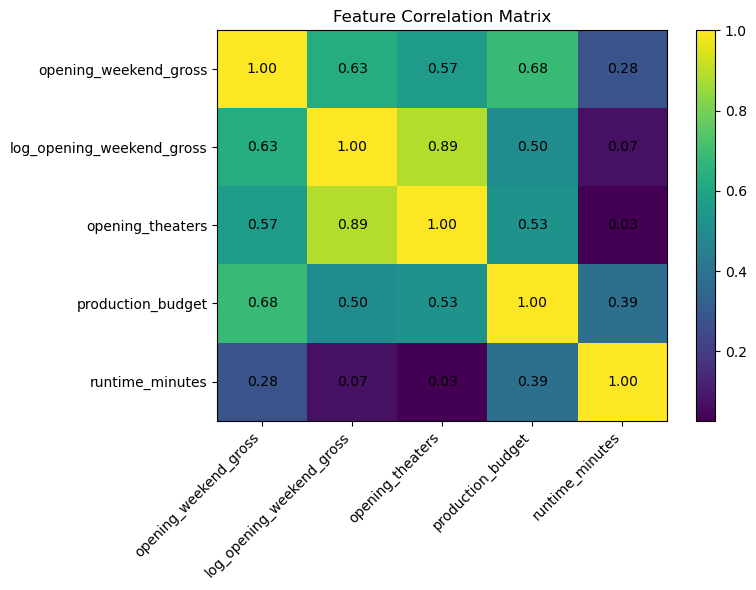

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Feature Correlation Matrix")
plt.colorbar(im)

plt.tight_layout()
plt.show()

In [12]:
genre_stats = (
    model_df
    .groupby("genre")["opening_weekend_gross"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

genre_stats

,count,mean,median
genre,,,
Action,350,4.403680e+07,25420212.5
Adventure,358,3.888995e+07,27280651.0
Musical,46,3.611847e+07,18549503.5
Reality,1,2.900200e+07,29002002.0
Concert/Performance,7,2.453361e+07,11767210.0
Horror,230,1.882233e+07,15139131.5
Comedy,388,1.621392e+07,12692117.5
Western,19,1.537129e+07,14035033.0
Thriller/Suspense,251,1.476188e+07,11581586.0


In [13]:
release_stats = (
    model_df
    .groupby("release_type")["opening_weekend_gross"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

release_stats

,count,mean,median
release_type,,,
Wide,1975,2.656150e+07,16207730.0
Expands Wide,18,3.135126e+06,568530.0
Limited,257,9.368810e+05,292177.0


In [14]:
source_stats = (
    model_df
    .groupby("source")["opening_weekend_gross"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

source_stats.head(20)

,count,mean,median
source,,,
Based on Theme Park Ride,6,7.710063e+07,76567605.5
Based on Comic/Graphic Novel,125,6.454224e+07,46110859.0
Spin-Off,42,5.743776e+07,50795182.5
Based on Toy,10,4.586839e+07,37308574.5
Based on Folk Tale/Legend/Fairytale,39,4.123594e+07,27202226.0
Based on TV,78,3.234074e+07,28552684.5
Based on Game,26,2.622236e+07,22044250.0
Based on Religious Text,8,2.397767e+07,10806972.5
Based on Fiction Book/Short Story,439,2.309328e+07,13501349.0


In [15]:
distributor_stats = (
    model_df
    .groupby("distributor")["opening_weekend_gross"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

distributor_stats.head(20)

,count,mean,median
distributor,,,
AMC Theatres Distribution,1,9.322476e+07,93224755.0
Warner Bros. (IMAX Fan First Exclusive),1,8.250539e+07,82505391.0
"Universal, released as Dr. Seuss' The Lorax",1,7.021707e+07,70217070.0
"Paramount Pictures, released as Madagascar 3: Europe's Most Wanted",1,6.031674e+07,60316738.0
"Warner Bros., released as Valentine's Day",1,5.626071e+07,56260707.0
Walt Disney,196,5.340222e+07,27384986.5
"Lionsgate, released as The Divergent Serires: Insurgent",1,5.226368e+07,52263680.0
"20th Century Fox, released as Mr. And Mrs. Smith",1,5.034288e+07,50342878.0
"Paramount Pictures, released as MegaMind",1,4.601683e+07,46016833.0


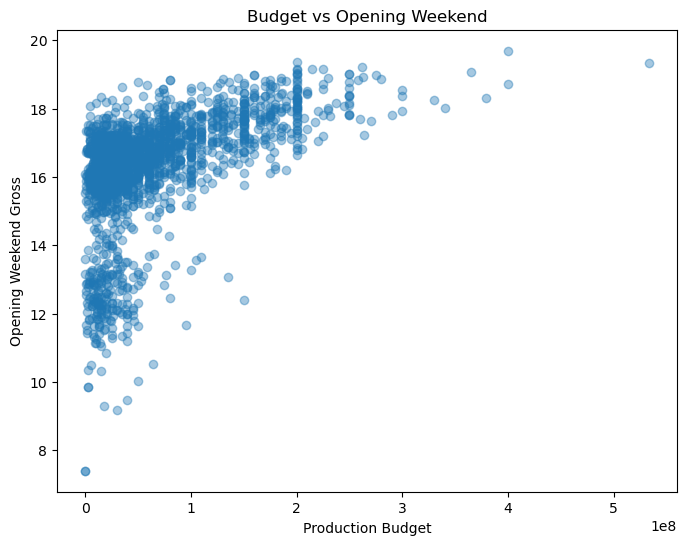

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    model_df["production_budget"],
    model_df["log_opening_weekend_gross"],
    alpha=0.4
)

ax.set_xlabel("Production Budget")
ax.set_ylabel("Opening Weekend Gross")

plt.title("Budget vs Opening Weekend")

plt.show()

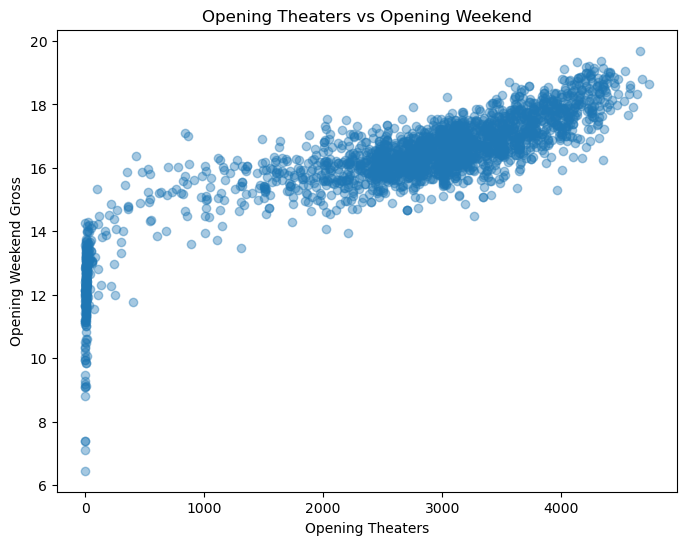

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    model_df["opening_theaters"],
    model_df["log_opening_weekend_gross"],
    alpha=0.4
)

ax.set_xlabel("Opening Theaters")
ax.set_ylabel("Opening Weekend Gross")

plt.title("Opening Theaters vs Opening Weekend")

plt.show()

In [21]:
model_df["domestic_release_date"] = pd.to_datetime(
    model_df["domestic_release_date"]
)

model_df["release_day_of_year"] = (
    model_df["domestic_release_date"]
    .dt.dayofyear
)

corr_cols = [
    "log_opening_weekend_gross",
    "release_day_of_year"
]

model_df[corr_cols].corr()

,log_opening_weekend_gross,release_day_of_year
log_opening_weekend_gross,1.000000,-0.228349
release_day_of_year,-0.228349,1.000000


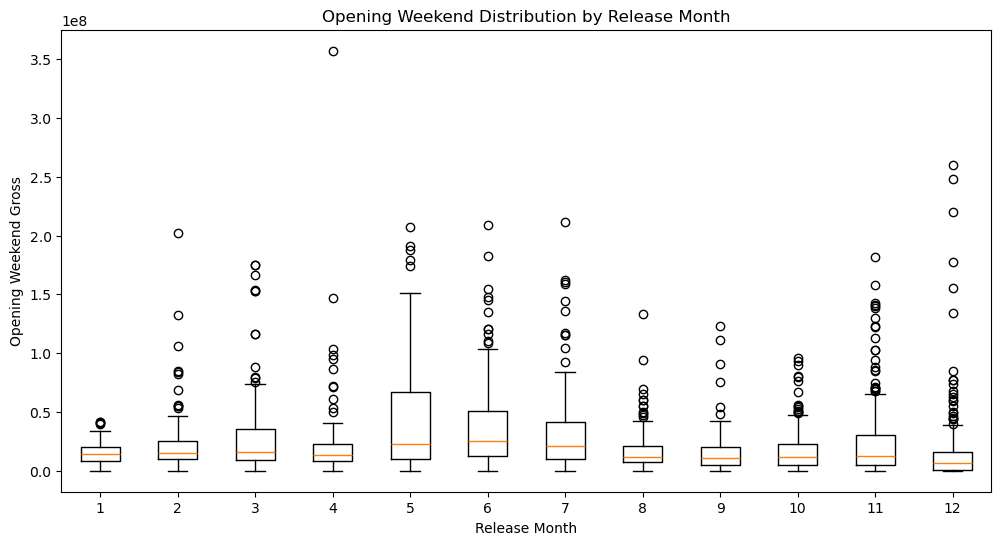

In [40]:
model_df["release_month"] = (
    model_df["domestic_release_date"]
    .dt.month
)

fig, ax = plt.subplots(figsize=(12, 6))

monthly_data = [
    model_df.loc[
        model_df["release_month"] == month,
        "opening_weekend_gross"
    ]
    for month in range(1, 13)
]

ax.boxplot(monthly_data)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(range(1, 13))

ax.set_xlabel("Release Month")
ax.set_ylabel("Opening Weekend Gross")

plt.title("Opening Weekend Distribution by Release Month")

plt.show()

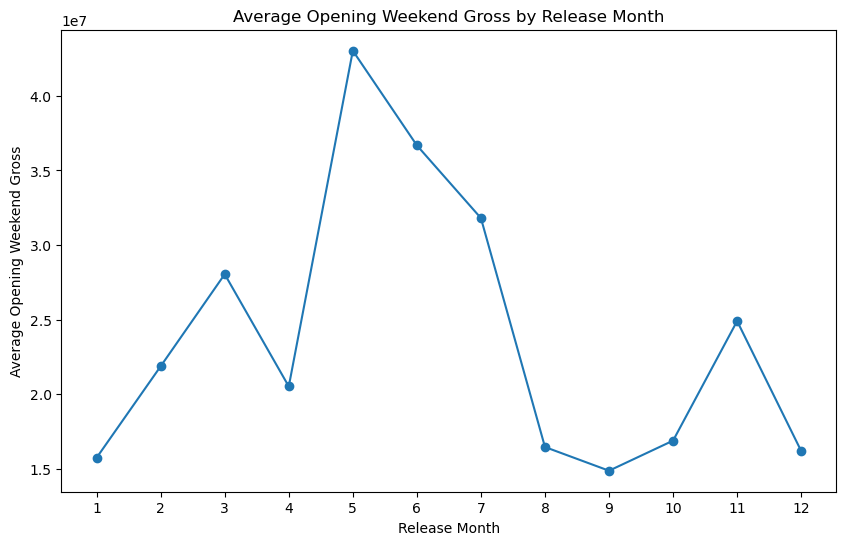

In [41]:
monthly_avg_log = (
    model_df
    .groupby("release_month")["opening_weekend_gross"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    monthly_avg_log.index,
    monthly_avg_log.values,
    marker="o"
)

ax.set_xticks(range(1, 13))

ax.set_xlabel("Release Month")
ax.set_ylabel("Average Opening Weekend Gross")

plt.title("Average Opening Weekend Gross by Release Month")

plt.show()

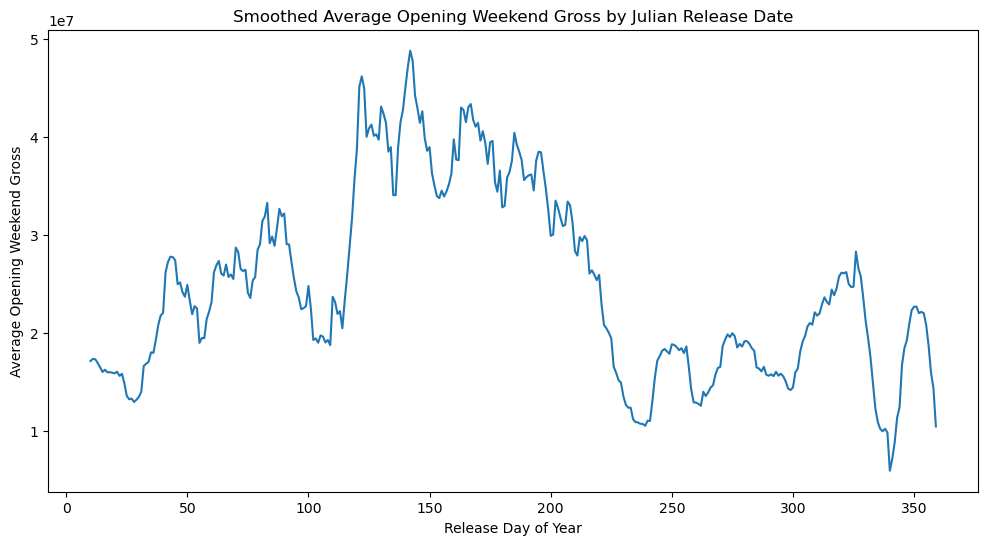

In [42]:
julian_avg_smooth = (
    model_df
    .groupby("release_day_of_year")["opening_weekend_gross"]
    .mean()
    .rolling(14, center=True)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    julian_avg_smooth.index,
    julian_avg_smooth.values
)

ax.set_xlabel("Release Day of Year")
ax.set_ylabel("Average Opening Weekend Gross")

plt.title("Smoothed Average Opening Weekend Gross by Julian Release Date")

plt.show()

In [51]:
def category_summary(df, col,targ="opening_weekend_gross", min_count=20):

    summary = (
        df
        .groupby(col)[targ]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )

    summary = summary[
        summary["count"] >= min_count
    ]

    return summary

In [52]:
creative_type_summary = category_summary(
    model_df,
    "creative_type"
)

creative_type_summary

,count,mean,median
creative_type,,,
Super Hero,100,8.435720e+07,69170572.5
Science Fiction,228,3.500089e+07,23357426.5
Kids Fiction,214,3.432760e+07,23699006.5
Fantasy,154,3.290505e+07,20098373.5
Contemporary Fiction,1127,1.625815e+07,12222756.0
Factual,20,1.599138e+07,5964316.5
Historical Fiction,190,1.574770e+07,10010958.0
Dramatization,215,1.052990e+07,7450275.0


C:\Users\sebas\AppData\Local\Temp\ipykernel_13416\2451264729.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


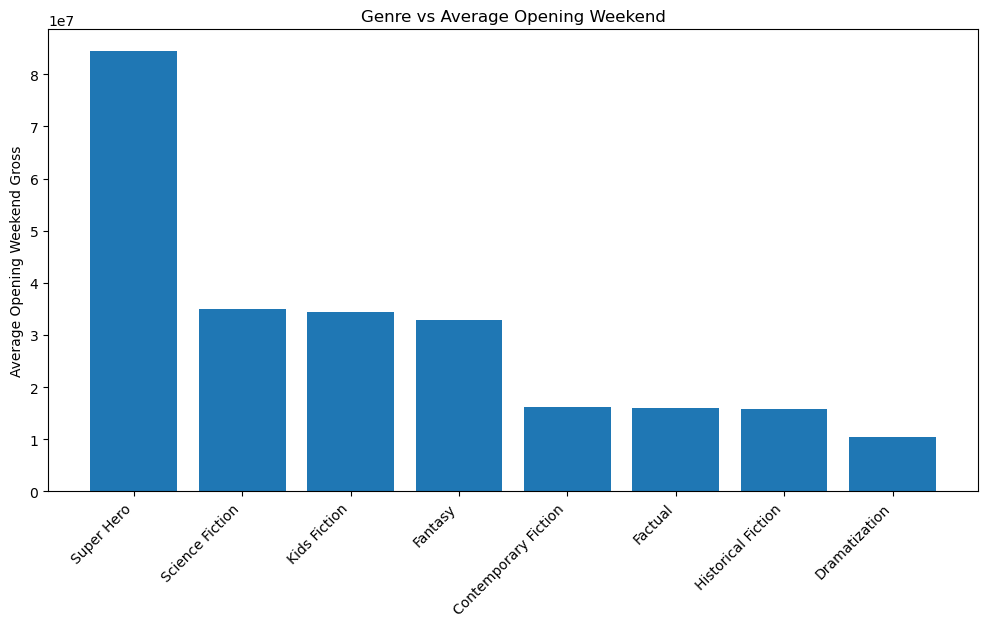

In [59]:
creative_type_summary_plot = (
    creative_type_summary
    .sort_values("mean", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    creative_type_summary_plot.index,
    creative_type_summary_plot["mean"]
)

ax.set_xticklabels(
    creative_type_summary_plot.index,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Average Opening Weekend Gross")

plt.title("Genre vs Average Opening Weekend")

plt.show()

In [35]:
source_summary = category_summary(
    model_df,
    "source"
)

source_summary

,count,mean,median
source,,,
Based on Comic/Graphic Novel,125,6.454224e+07,46110859.0
Spin-Off,42,5.743776e+07,50795182.5
Based on Folk Tale/Legend/Fairytale,39,4.123594e+07,27202226.0
Based on TV,78,3.234074e+07,28552684.5
Based on Game,26,2.622236e+07,22044250.0
Based on Fiction Book/Short Story,439,2.309328e+07,13501349.0
Original Screenplay,1169,1.904902e+07,12701743.0
Based on Factual Book/Article,91,1.447980e+07,8913698.0
Based on Play,26,1.211213e+07,9089057.5


C:\Users\sebas\AppData\Local\Temp\ipykernel_13416\35910281.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


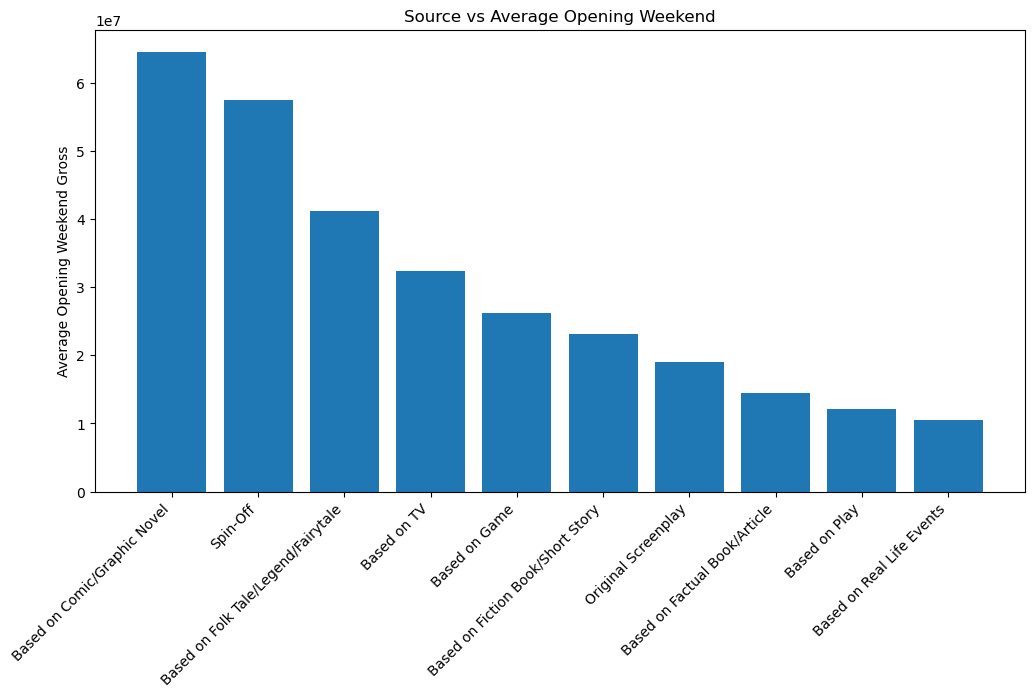

In [58]:
source_summary_plot = (
    source_summary
    .sort_values("mean", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    source_summary_plot.index,
    source_summary_plot["mean"]
)

ax.set_xticklabels(
    source_summary_plot.index,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Average Opening Weekend Gross")

plt.title("Source vs Average Opening Weekend")

plt.show()

In [56]:
source_legs_summary = category_summary(
    model_df,
    "source",
    "legs"
)

source_legs_summary

,count,mean,median
source,,,
Based on Real Life Events,155,5.213355,3.690
Based on Play,26,4.665769,3.545
Based on Factual Book/Article,91,4.171758,3.730
Based on Fiction Book/Short Story,439,3.727768,3.210
Original Screenplay,1169,3.480573,2.990
Spin-Off,42,3.199762,2.880
Based on TV,78,3.162692,2.960
Based on Folk Tale/Legend/Fairytale,39,3.060000,2.850
Based on Comic/Graphic Novel,125,2.958560,2.720


C:\Users\sebas\AppData\Local\Temp\ipykernel_13416\780815707.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


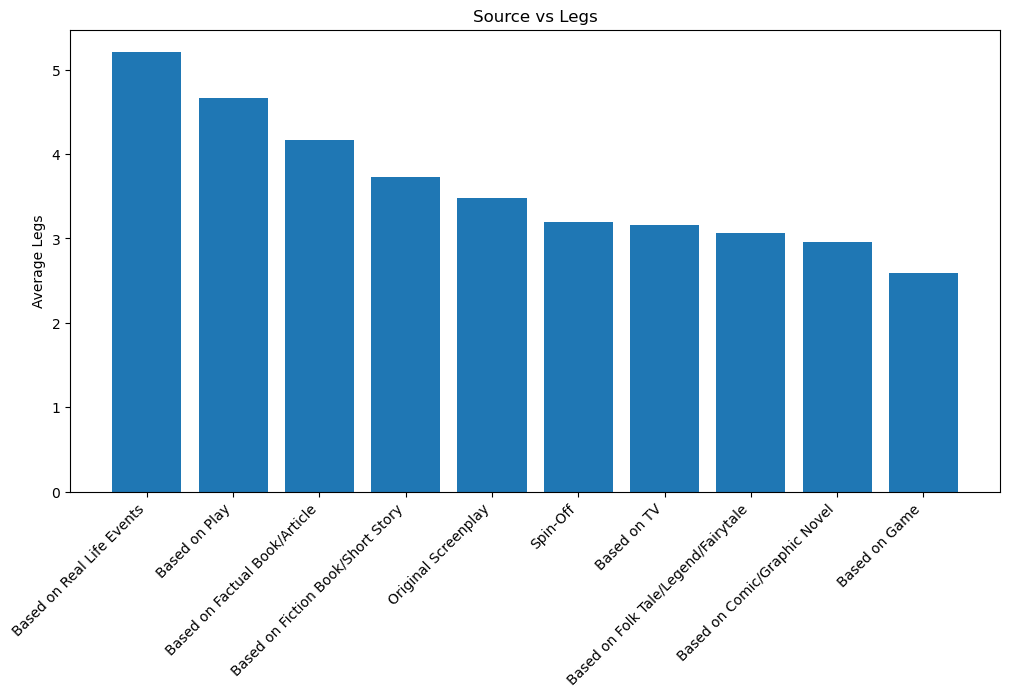

In [57]:
source_legs_summary_plot = (
    source_legs_summary
    .sort_values("mean", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    source_legs_summary_plot.index,
    source_legs_summary_plot["mean"]
)

ax.set_xticklabels(
    source_legs_summary_plot.index,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Average Legs")

plt.title("Source vs Legs")

plt.show()

In [63]:
genres_summary = category_summary(
    model_df,
    "genre",
)

genres_summary

,count,mean,median
genre,,,
Action,350,4.403680e+07,25420212.5
Adventure,358,3.888995e+07,27280651.0
Musical,46,3.611847e+07,18549503.5
Horror,230,1.882233e+07,15139131.5
Comedy,388,1.621392e+07,12692117.5
Thriller/Suspense,251,1.476188e+07,11581586.0
Romantic Comedy,124,1.370903e+07,12005577.5
Drama,427,1.129031e+07,6773870.0
Black Comedy,40,9.243041e+06,9268691.0


C:\Users\sebas\AppData\Local\Temp\ipykernel_13416\2388867275.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


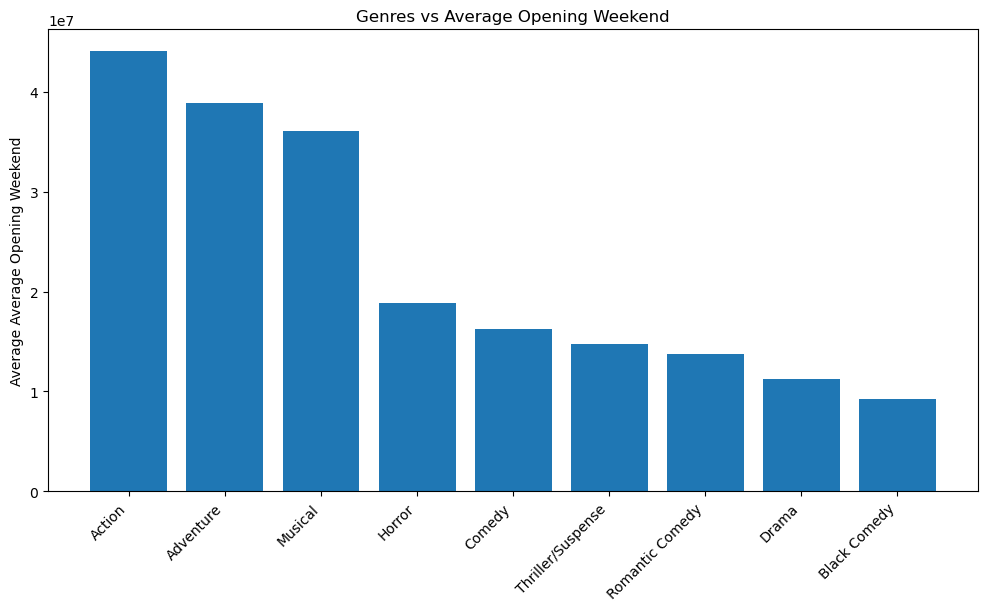

In [64]:
genres_summary_plot = (
    genres_summary
    .sort_values("mean", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    genres_summary_plot.index,
    genres_summary_plot["mean"]
)

ax.set_xticklabels(
    genres_summary_plot.index,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Average Average Opening Weekend")

plt.title("Genres vs Average Opening Weekend")

plt.show()

In [61]:
genres_legs_summary = category_summary(
    model_df,
    "genre",
    "legs"
)

genres_legs_summary

,count,mean,median
genre,,,
Drama,427,4.761522,3.710
Black Comedy,40,4.747500,3.320
Musical,46,4.685000,4.130
Comedy,388,3.581469,3.140
Adventure,358,3.555978,3.380
Romantic Comedy,124,3.547339,3.185
Thriller/Suspense,251,3.226494,2.940
Action,350,2.895943,2.670
Horror,230,2.598957,2.460


C:\Users\sebas\AppData\Local\Temp\ipykernel_13416\2260819838.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


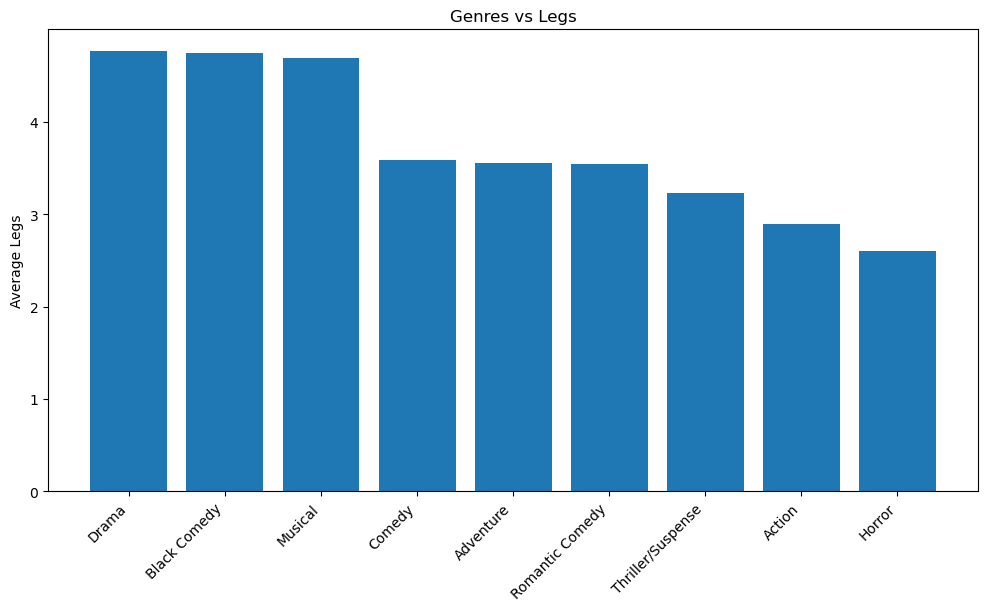

In [62]:
genres_legs_summary_plot = (
    genres_legs_summary
    .sort_values("mean", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    genres_legs_summary_plot.index,
    genres_legs_summary_plot["mean"]
)

ax.set_xticklabels(
    genres_legs_summary_plot.index,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Average Legs")

plt.title("Genres vs Legs")

plt.show()

Note:
These patterns may partially reflect survivorship bias. The dataset primarily contains films that achieved identifiable theatrical releases and matched commercial reporting pages. Genres with strong audience retention (high legs) may still appear less frequently if studios perceive them as riskier or less scalable commercially.
